<a href="https://colab.research.google.com/github/RGarancs/applied-ai-academy-labs/blob/main/solutions/usedcars.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Used cars — depreciation & price (case study)

**Applied AI Academy — problem set with worked answers**

**Used in:** Lesson 8 — Build, buy, rent, or open — sourcing is strategy, not procurement  
**Rows:** 10,000  ·  **Source file:** `ss_used_cars.csv`



---
### How to use this notebook
Run the cells in order. Each problem is stated first, then solved, then the
answer is spelled out. For teaching, hide the solution cells and let the room
attempt the task before revealing them.

> The data loads straight from `appliedai.center` — nothing to upload.


## Setup

In [1]:
%matplotlib inline
import pandas as pd, numpy as np, os, urllib.request
import matplotlib, matplotlib.pyplot as plt
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)

# Applied AI Academy chart style — calm, legible when projected
INK, ACCENT, CORE, BUILDER, DANGER = "#26214a", "#544d94", "#5b8a6e", "#a8845c", "#b05a5a"
matplotlib.rcParams.update({
    "figure.figsize": (9, 4.5), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#c9c4d8", "axes.labelcolor": INK, "axes.titlesize": 13,
    "axes.titleweight": "600", "axes.titlecolor": INK, "axes.titlepad": 14,
    "text.color": INK, "xtick.color": INK, "ytick.color": INK,
    "font.size": 10, "grid.color": "#e6e2ef", "axes.grid": True,
    "axes.axisbelow": True, "grid.linewidth": .8, "figure.facecolor": "white",
})

URL   = "https://appliedai.center/assets/datasets/ss_used_cars.csv"
LOCAL = "ss_used_cars.csv"
if not os.path.exists(LOCAL):
    print("Downloading", URL)
    urllib.request.urlretrieve(URL, LOCAL)

df = pd.read_csv(LOCAL, low_memory=False)
print("Shape:", df.shape)
df.head()

Shape: (10000, 33)


,brand,model,year,age_years,year_cluster,price_eur,price_band,mileage_km,mileage_th_km,mileage_band,engine,engine_volume_l,engine_type,transmission,body_type,car_type_cluster,color,location,listing_type,technical_inspection,photo_count,description_length,has_phone,has_vin,date_posted,scraped_at_utc,page_title,meta_description,source_url,phone_masked,vin_code,ad_id,stable_row_id
0,Alfa Romeo,147,2004,22,Older (11y+),18900.0,15k-30k €,93964.0,93.964,50k-100k km,3.2 benzīns,3.2,Petrol,Manuāla 6 ātrumi,Hečbeks,City hatchback type,Melna metālika,Rīga,Pārdod,07.2027,26,0,True,False,46194.761111,46209.803970,"SS.COM Alfa Romeo 147, Cena 18 900 €. Alfa Rom...","Sludinājumi. Vieglie auto - Alfa Romeo - 147, ...",https://www.ss.com/msg/lv/transport/cars/alfa-...,(+371)29-19-***,Parādīt vin kodu,gkplb,gkplb-2275354422ca
1,Alfa Romeo,147,2006,20,Older (11y+),820.0,<1k €,188720.0,188.720,150k-200k km,1.6 benzīns,1.6,Petrol,Manuāla,Hečbeks,City hatchback type,Zila,Jelgava un raj.,Pārdod,08.2026,9,0,True,False,46203.724306,46209.803959,"SS.COM Alfa Romeo 147, Cena 820 €. Pārdodās Al...","Sludinājumi. Vieglie auto - Alfa Romeo - 147, ...",https://www.ss.com/msg/lv/transport/cars/alfa-...,(+371)28-34-***,Parādīt vin kodu,cxepi,cxepi-9d87aaa330fb
2,Alfa Romeo,147,2010,16,Older (11y+),1000.0,1k-3k €,202000.0,202.000,200k-300k km,1.6 benzīns,1.6,Petrol,Manuāla 5 ātrumi,Hečbeks,City hatchback type,Melna,Rīga,Pārdod,08.2026,5,0,True,False,46193.665278,46209.803970,"SS.COM Alfa Romeo 147, Cena 1 000 €. Продам ав...","Sludinājumi. Vieglie auto - Alfa Romeo - 147, ...",https://www.ss.com/msg/lv/transport/cars/alfa-...,(+371)26-90-***,Parādīt vin kodu,gjcln,gjcln-7b528a1b17cc
3,Alfa Romeo,155,1996,30,Older (11y+),9900.0,7k-15k €,109133.0,109.133,100k-150k km,2.5 benzīns,2.5,Petrol,Manuāla 5 ātrumi,Sedans,Business sedan type,Sudraba metālika,Rīga,Pārdod,Bez apskates,18,0,True,False,46190.279861,46209.803985,"SS.COM Alfa Romeo 155, Cena 9 900 €. Pārdod 19...","Sludinājumi. Vieglie auto - Alfa Romeo - 155, ...",https://www.ss.com/msg/lv/transport/cars/alfa-...,(+371)29-10-***,Parādīt vin kodu,himnj,himnj-de27059dd721
4,Alfa Romeo,156,2000,26,Older (11y+),700.0,<1k €,258000.0,258.000,200k-300k km,1.9 dīzelis,1.9,Diesel,Manuāla,Sedans,Business sedan type,Zila,Rīga,Pārdod,01.2027,14,0,True,False,46180.464583,46209.803955,"SS.COM Alfa Romeo 156, Cena 700 €. Alfa Romeo ...","Sludinājumi. Vieglie auto - Alfa Romeo - 156, ...",https://www.ss.com/msg/lv/transport/cars/alfa-...,(+371)26-61-***,Parādīt vin kodu,fhgfh,fhgfh-5159428356da


## What is in the file

In [2]:
print("Columns and types:")
print(df.dtypes.to_string())
miss = df.isna().sum()
miss = miss[miss > 0]
print("\nMissing values:" if len(miss) else "\nNo missing values.")
if len(miss): print(miss.to_string())

Columns and types:
brand                       str
model                       str
year                      int64
age_years                 int64
year_cluster                str
price_eur               float64
price_band                  str
mileage_km              float64
mileage_th_km           float64
mileage_band                str
engine                      str
engine_volume_l         float64
engine_type                 str
transmission                str
body_type                   str
car_type_cluster            str
color                       str
location                    str
listing_type                str
technical_inspection        str
photo_count               int64
description_length        int64
has_phone                  bool
has_vin                    bool
date_posted             float64
scraped_at_utc          float64
page_title                  str
meta_description            str
source_url                  str
phone_masked                str
vin_code             

---
## Problem 1 · Easy — describe

How does median price fall with age (0–5 / 6–10 / 11+ years)? Which 3 brands hold value best? Is the price–mileage relationship linear or curved?

*Try it yourself first. The worked solution is below.*

In [3]:
print(f"Listings: {len(df):,}")
print(f"Median price: EUR {df['price_eur'].median():,.0f}")
print("\nTop brands:\n", df["brand"].value_counts().head(10))
print("\nPrice by age band:")
print(df.groupby("mileage_band")["price_eur"].agg(n="size", median="median").round(0))
print(f"\nCorrelation age vs price:     {df['age_years'].corr(df['price_eur']):.2f}")
print(f"Correlation mileage vs price: {df['mileage_km'].corr(df['price_eur']):.2f}")

Listings: 10,000
Median price: EUR 8,200

Top brands:
 brand
BMW           3446
Audi          2396
Ford           967
Mercedes       391
Citroen        376
Hyundai        360
Land Rover     334
Kia            269
Lexus          191
Mazda          178
Name: count, dtype: int64

Price by age band:
                 n   median
mileage_band               
100k-150k km   774  16600.0
150k-200k km  1237  12590.0
200k-300k km  3364   7850.0
300k-500k km  2187   4300.0
500k+ km        50   2325.0
50k-100k km    597  23700.0
<50k km       1791   9900.0

Correlation age vs price:     -0.61
Correlation mileage vs price: -0.60


---
## Problem 2 · Intermediate — build

Train a regression on age, mileage, engine_volume, brand, body_type. Compare a linear model vs gradient-boosted trees on MAE. Where does linear fail (luxury brands, very old cars)?

*Try it yourself first. The worked solution is below.*

In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

d = df.dropna(subset=["price_eur","age_years","mileage_km","engine_volume_l"]).copy()
d = d[d.price_eur.between(300, 150_000)]
feat = ["age_years","mileage_km","engine_volume_l","brand","transmission","engine_type","body_type"]
X = pd.get_dummies(d[feat], drop_first=True)
y = d["price_eur"]
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=.25, random_state=42)

lin = LinearRegression().fit(Xtr, ytr)
rf  = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1).fit(Xtr, ytr)
mae_lin = mean_absolute_error(yte, lin.predict(Xte))
mae_rf  = mean_absolute_error(yte, rf.predict(Xte))
print(f"n = {len(d):,}")
print(f"Linear MAE: EUR {mae_lin:,.0f}")
print(f"Forest MAE: EUR {mae_rf:,.0f}   ({(1-mae_rf/mae_lin):.0%} better)")
print("\nDepreciation is non-linear, so a tree beats a straight line here.")
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nTop features:\n", imp.head(6).round(3))

n = 8,420
Linear MAE: EUR 4,756
Forest MAE: EUR 2,405   (49% better)

Depreciation is non-linear, so a tree beats a straight line here.

Top features:
 age_years            0.562
engine_volume_l      0.233
mileage_km           0.127
brand_BMW            0.010
body_type_Apvidus    0.007
brand_Mercedes       0.005
dtype: float64


---
## Problem 3 · Advanced — judge

Model log(price) and quantify each brand's "premium" after controlling for age & mileage. Argue: does this problem justify deep learning, or would explainable trees win in a regulated resale context? Write the deployment checklist.

*Try it yourself first. The worked solution is below.*

In [5]:
import numpy as np
d = df.dropna(subset=["price_eur","age_years"]).copy()
d = d[d.price_eur.between(300, 150_000) & d.age_years.between(0, 30)]
curve = d.groupby("age_years")["price_eur"].median()
print("Median price by age (EUR):\n", curve.head(16).round(0))

first = curve.loc[curve.index <= 1].mean()
y5 = curve.loc[curve.index.isin([5])].mean()
if first and y5:
    print(f"\nValue retained at 5 years: {y5/first:.0%}")
print("""
Where a model like this must NOT be used
  · as a trade-in offer without a physical inspection (condition is absent)
  · on brands/models with very few listings — the estimate is noise
  · on ASKING prices as if they were sale prices; sellers negotiate down
""")

Median price by age (EUR):
 age_years
0     31900.0
1     50500.0
2     41950.0
3     34900.0
4     28500.0
5     24200.0
6     21250.0
7     18900.0
8     17500.0
9     15000.0
10    12790.0
11    12500.0
12    10250.0
13     8700.0
14     8300.0
15     6990.0
Name: price_eur, dtype: float64

Value retained at 5 years: 59%

Where a model like this must NOT be used
  · as a trade-in offer without a physical inspection (condition is absent)
  · on brands/models with very few listings — the estimate is noise
  · on ASKING prices as if they were sale prices; sellers negotiate down



---
## Visual summary

The same answers, as pictures. These are what to project — a room reads a chart
far faster than it reads a table, and the shape of a result is usually the
argument you are actually making.

findfont: Failed to find font weight 600, now using 700.


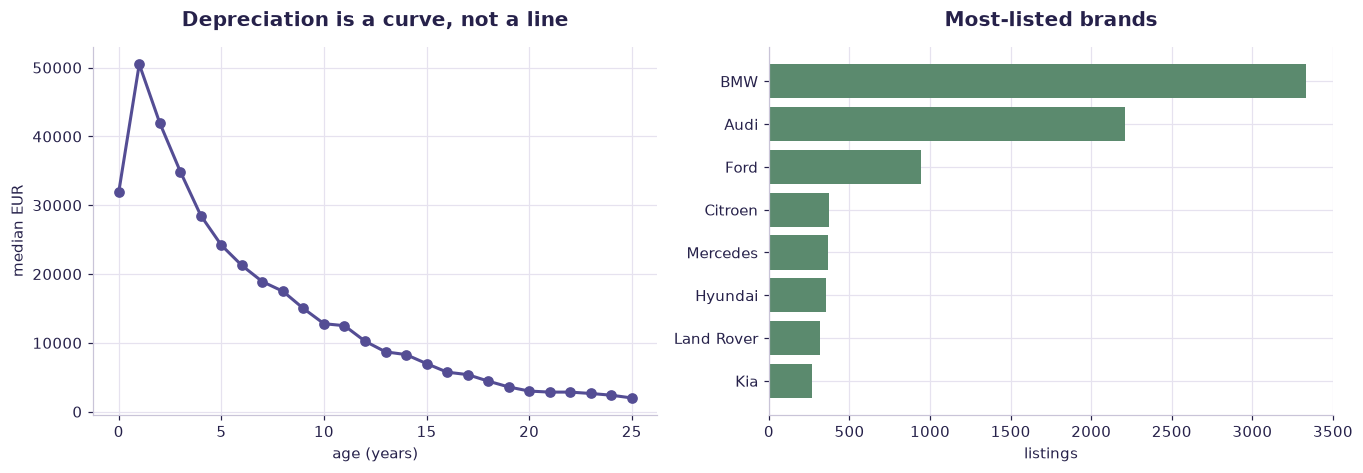

In [6]:
d = df[df.price_eur.between(300, 150_000) & df.age_years.between(0, 25)]
fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.4))
curve = d.groupby("age_years")["price_eur"].median()
ax[0].plot(curve.index, curve.values, marker="o", color=ACCENT, lw=2)
ax[0].set_title("Depreciation is a curve, not a line"); ax[0].set_xlabel("age (years)"); ax[0].set_ylabel("median EUR")

b = d["brand"].value_counts().head(8).sort_values()
ax[1].barh(b.index, b.values, color=CORE)
ax[1].set_title("Most-listed brands"); ax[1].set_xlabel("listings")
plt.tight_layout(); plt.show()

---
## Verified answer key

These are the numbers the academy ships for this dataset. They were computed
from this exact file — if your run disagrees, reconcile before teaching it.

1. Median price €8,200. Depreciation is steep and non-linear: 0–5y median €30,900 → 6–10y €16,100 → 11+ €5,550
2. Most-listed brands: BMW (3,446), Audi (2,396), Ford (967) — a German-heavy Baltic market
3. Price–mileage and price–age are CURVED (exponential decay) — a linear model underprices new cars and overprices old ones; log-price or trees fix it
4. Great "model choice court": trees usually beat a plain linear model here, but explainability may still favour the simpler model for a resale guarantee


---
## Teaching notes

* **Run the Easy problem live.** It sets the shared vocabulary and gets everyone
  looking at the same rows.
* **Let them fail on the Intermediate one.** The productive mistake is usually
  reaching for a model before checking the data.
* **Argue about the Advanced one.** It has no single right answer; it has a
  defensible one, and defending it is the skill being taught.
* **Always close on limitations.** Every dataset here has a real caveat —
  scrape bias, a tiny sample, a hindsight label. Naming it is the lesson.
* **Deliverable for learners:** Vendor scorecard + a one-paragraph sourcing recommendation with the two assumptions that would change it.

---
*Applied AI Academy · appliedai.center*
